In [39]:
# Imports
import glob
import os
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.fallback"] = "stix"
plt.style.use("seaborn-v0_8-deep")
COLORS  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
MARKERS = ["o", "s", "^", "D"]

In [40]:
# Parameters
batch    = "L32_OBC_m400"
base_dir = rf"C:\Users\liamc\Documents\majorana_chain_dynamics\results\{batch}"
i_ref    = 15    # reference site
g_corr   = 0.42   # g/t value for correlation plots

In [28]:
# File discovery
def discover_files(base_dir):
    index = {}
    for fpath in glob.glob(os.path.join(base_dir, "**", "output.h5"), recursive=True):
        folder = os.path.basename(os.path.dirname(fpath))
        gm = re.search(r"g(-?[\d.]+)", folder)
        pm = re.search(r"p(even|odd)", folder)
        if gm and pm:
            g      = float(gm.group(1))
            parity = 1 if pm.group(1) == "even" else -1
            index[(g, parity)] = fpath
    return index

index = discover_files(base_dir)

with h5py.File(next(iter(index.values())), "r") as f:
    L = np.array(f["X"]).shape[0]

print(f"Found {len(index)} files | L = {L}")

Found 402 files | L = 32


In [29]:
# Load one HDF5 file
def load_file(fpath):
    with h5py.File(fpath, "r") as f:
        energies = f["energies"][:]
        nstates  = len(energies)
        g        = float(f["g"][()])
        t        = float(f["t"][()])
        parity   = int(f["parity"][()])
        X  = np.array(f["X"]).T
        Y  = np.array(f["Y"]).T
        Z  = np.array(f["Z"]).T
        L_ = X.shape[1]
        XX = np.array(f["XX"]).T.reshape(nstates, L_, L_)
        YY = np.array(f["YY"]).T.reshape(nstates, L_, L_)
        ZZ = np.array(f["ZZ"]).T.reshape(nstates, L_, L_)

    # Connected correlations
    XXc = XX - X[:, :, None] * X[:, None, :]
    YYc = YY - Y[:, :, None] * Y[:, None, :]
    ZZc = ZZ - Z[:, :, None] * Z[:, None, :]

    return dict(energies=energies, g=g, t=t, parity=parity, L=L_,
                XX=XX, YY=YY, ZZ=ZZ, XXc=XXc, YYc=YYc, ZZc=ZZc)

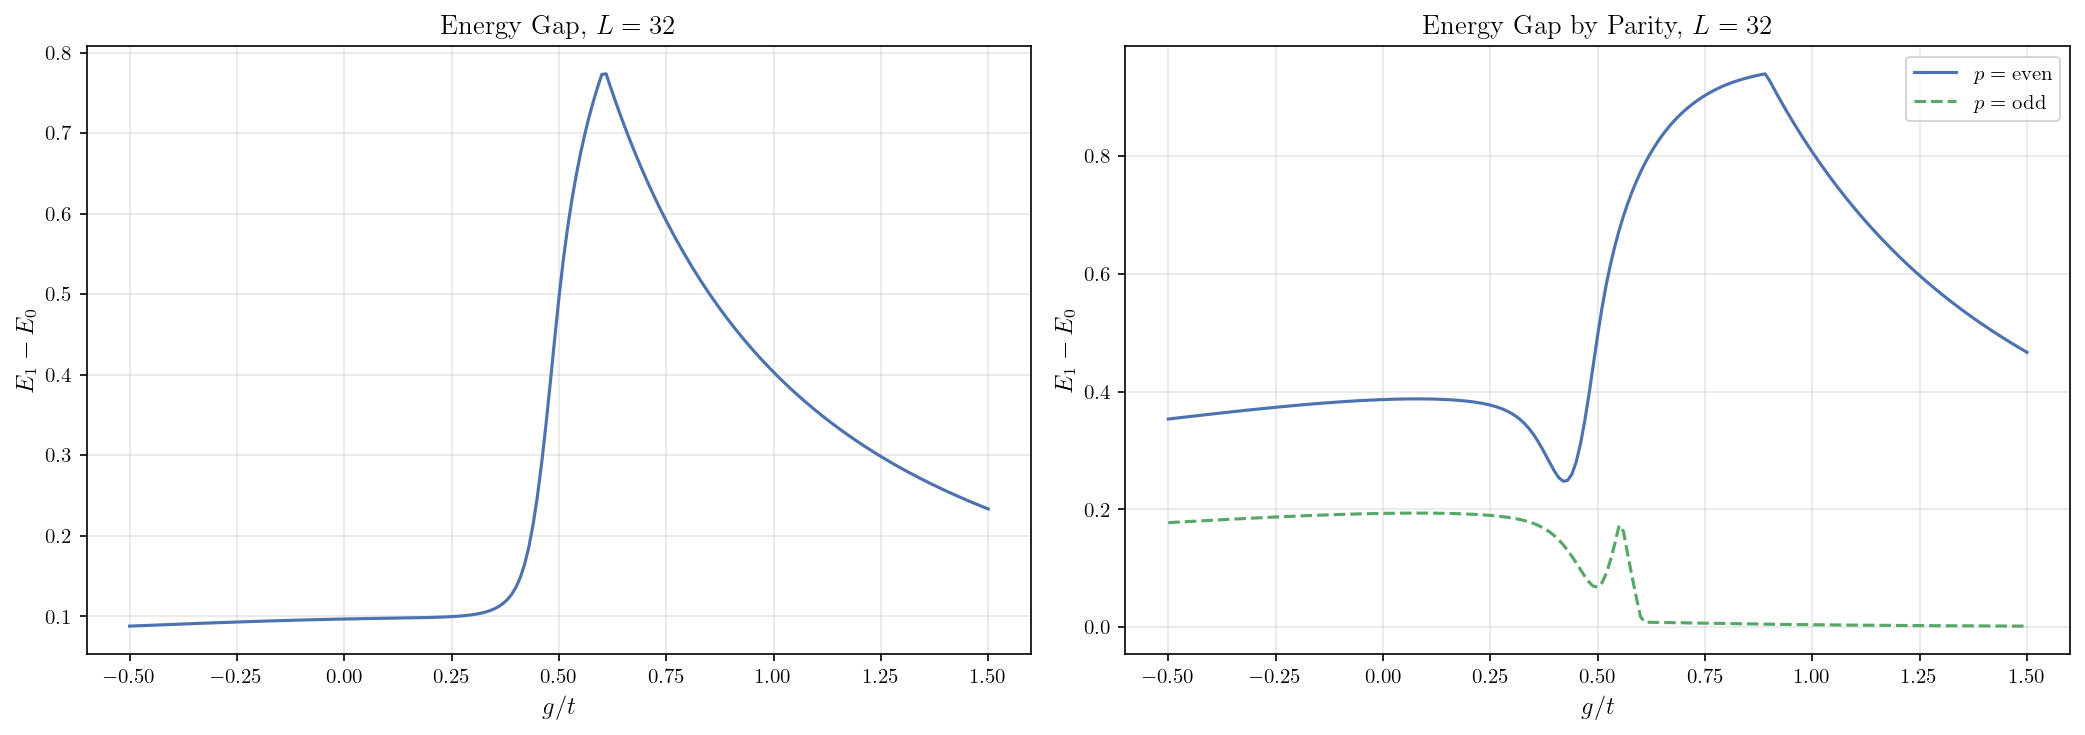

In [38]:
# Energy gap
g_set = sorted(set(g for (g, _) in index))
gaps  = []
for g in g_set:
    energies = []
    for parity in (1, -1):
        if (g, parity) in index:
            energies.extend(load_file(index[(g, parity)])["energies"])
    energies = sorted(energies)
    gaps.append(energies[1] - energies[0] if len(energies) >= 2 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

axes[0].plot(g_set, gaps, "-", color=COLORS[0], linewidth=1.5)
axes[0].set_xlabel(r"$g/t$", fontsize=12)
axes[0].set_ylabel(r"$E_1 - E_0$", fontsize=12)
axes[0].set_title(rf"Energy Gap, $L = {L}$", fontsize=13)
axes[0].grid(True, alpha=0.3)

for i, parity in enumerate((1, -1)):
    g_vals, intra_gaps = [], []
    for g in sorted(set(g for (g, p) in index if p == parity)):
        data = load_file(index[(g, parity)])
        es   = sorted(data["energies"])
        if len(es) >= 2:
            g_vals.append(g)
            intra_gaps.append(es[1] - es[0])
    p_str = r"\mathrm{even}" if parity == 1 else r"\mathrm{odd}"
    ls = "-" if parity == 1 else "--"
    axes[1].plot(g_vals, intra_gaps, linestyle=ls,
                 label=rf"$p={p_str}$",
                 color=COLORS[i], linewidth=1.5)

axes[1].set_xlabel(r"$g/t$", fontsize=12)
axes[1].set_ylabel(r"$E_1 - E_0$", fontsize=12)
axes[1].set_title(rf"Energy Gap by Parity, $L = {L}$", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

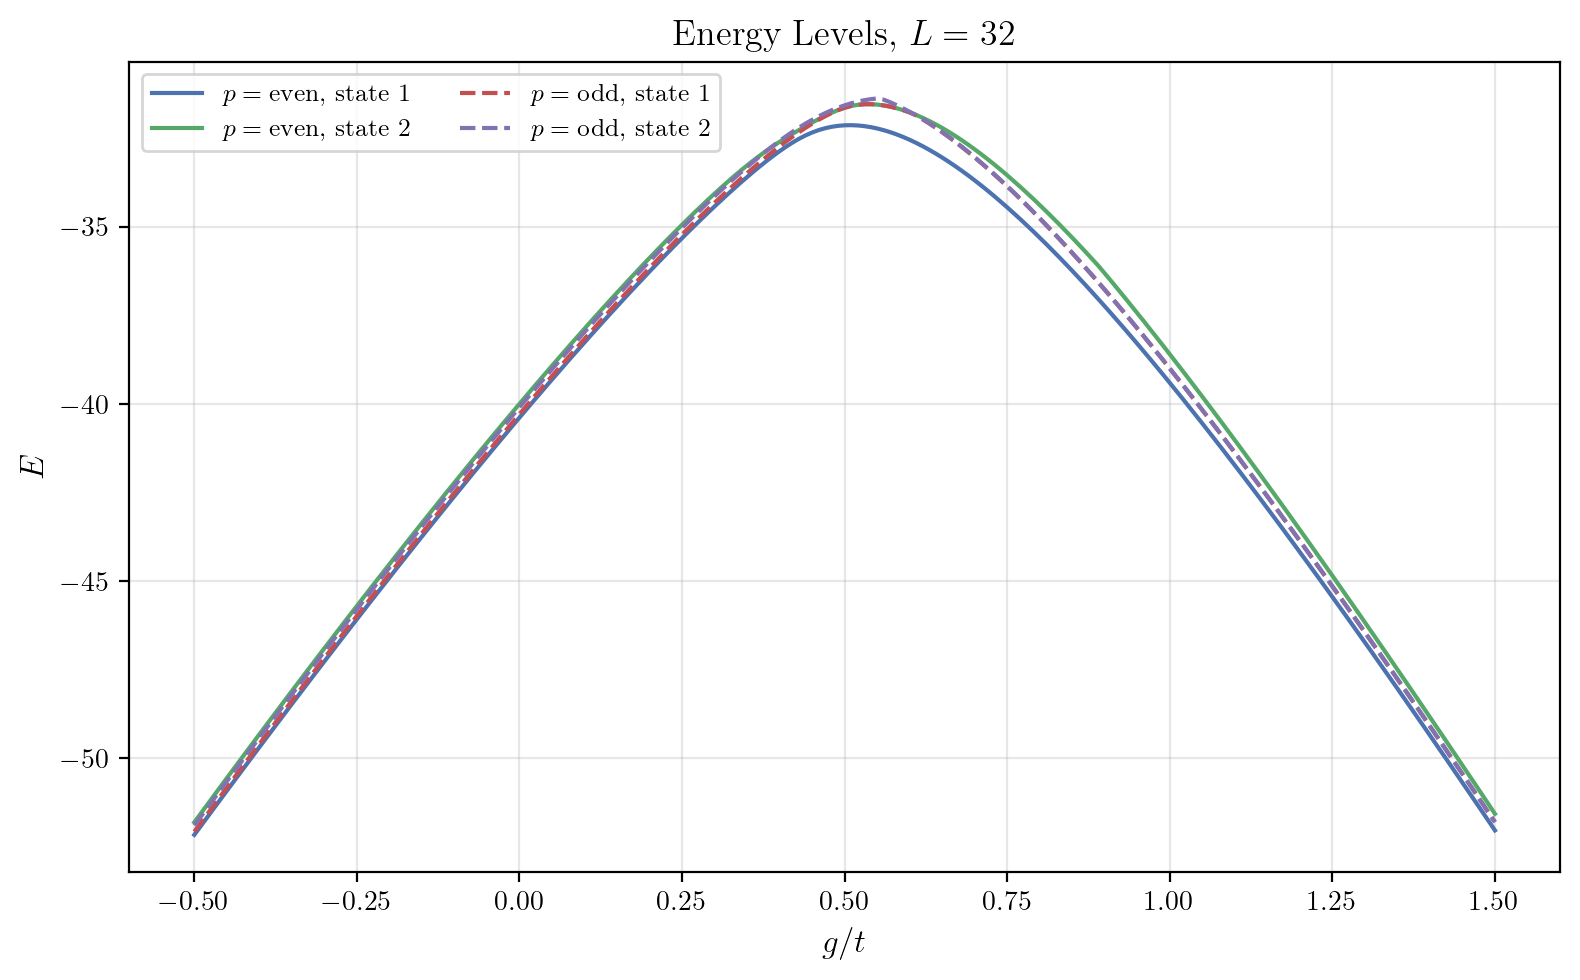

In [37]:
# Energy levels
series = {}
for (g, parity), fpath in sorted(index.items()):
    data = load_file(fpath)
    for k, e in enumerate(data["energies"]):
        p_str = "even" if parity == 1 else "odd"
        label = rf"$p=\mathrm{{{p_str}}}$, state {k+1}"
        series.setdefault(label, ([], [], parity))[0].append(g)
        series[label][1].append(e)

fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
for i, (label, (gs, es, parity)) in enumerate(sorted(series.items())):
    order = np.argsort(gs)
    ls = "-" if parity == 1 else "--"
    ax.plot(np.array(gs)[order], np.array(es)[order],
            linestyle=ls, label=label,
            color=COLORS[i % len(COLORS)], linewidth=1.5)
ax.set_xlabel(r"$g/t$", fontsize=12)
ax.set_ylabel(r"$E$", fontsize=12)
ax.set_title(rf"Energy Levels, $L = {L}$", fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

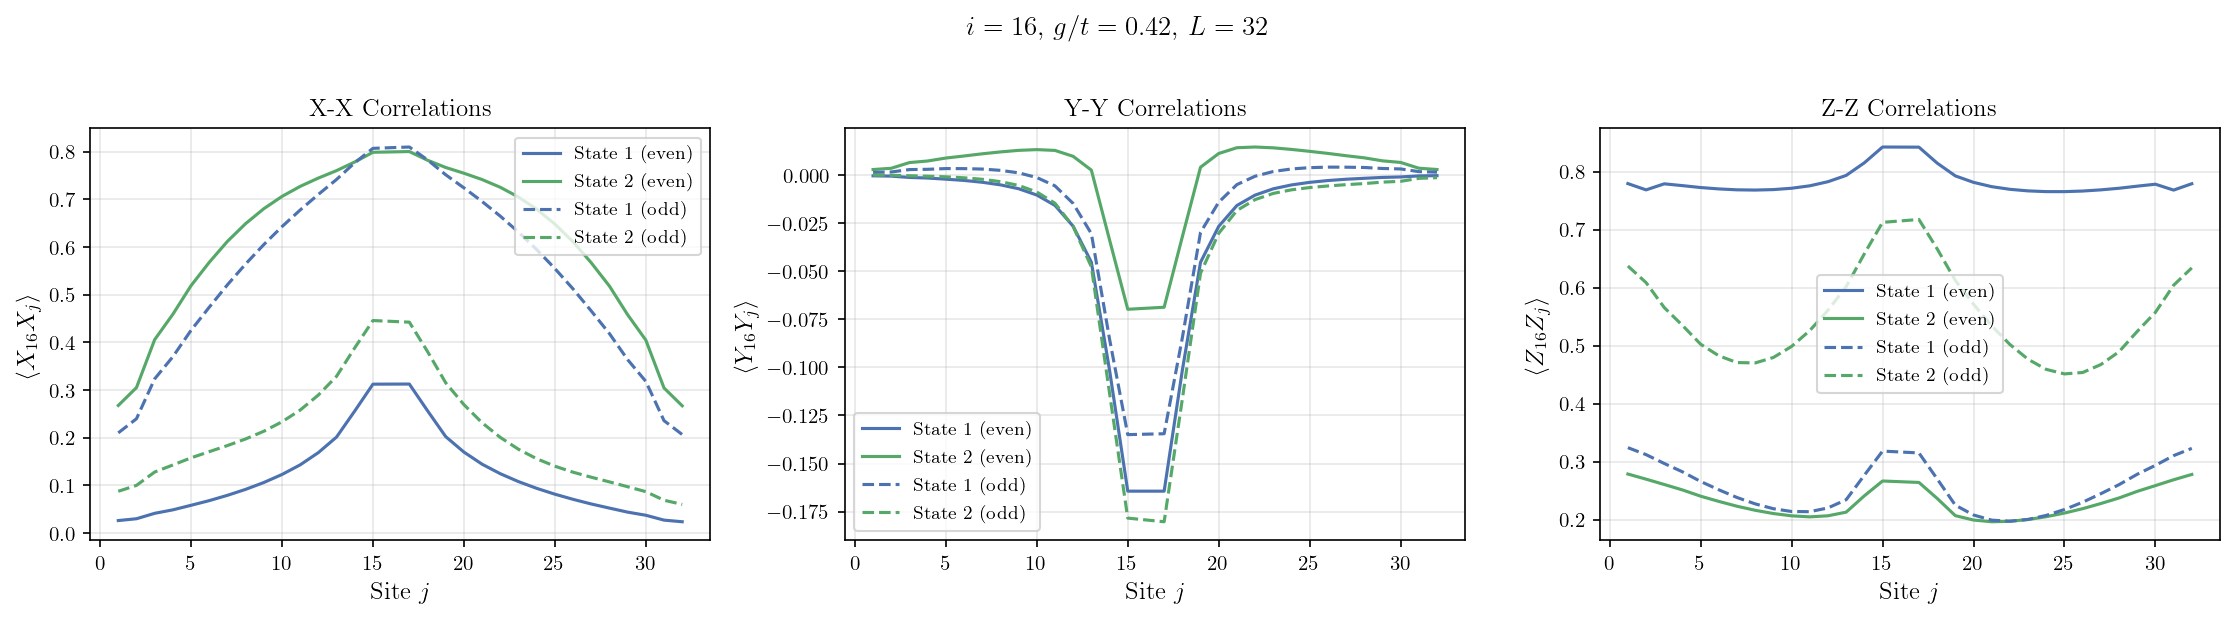

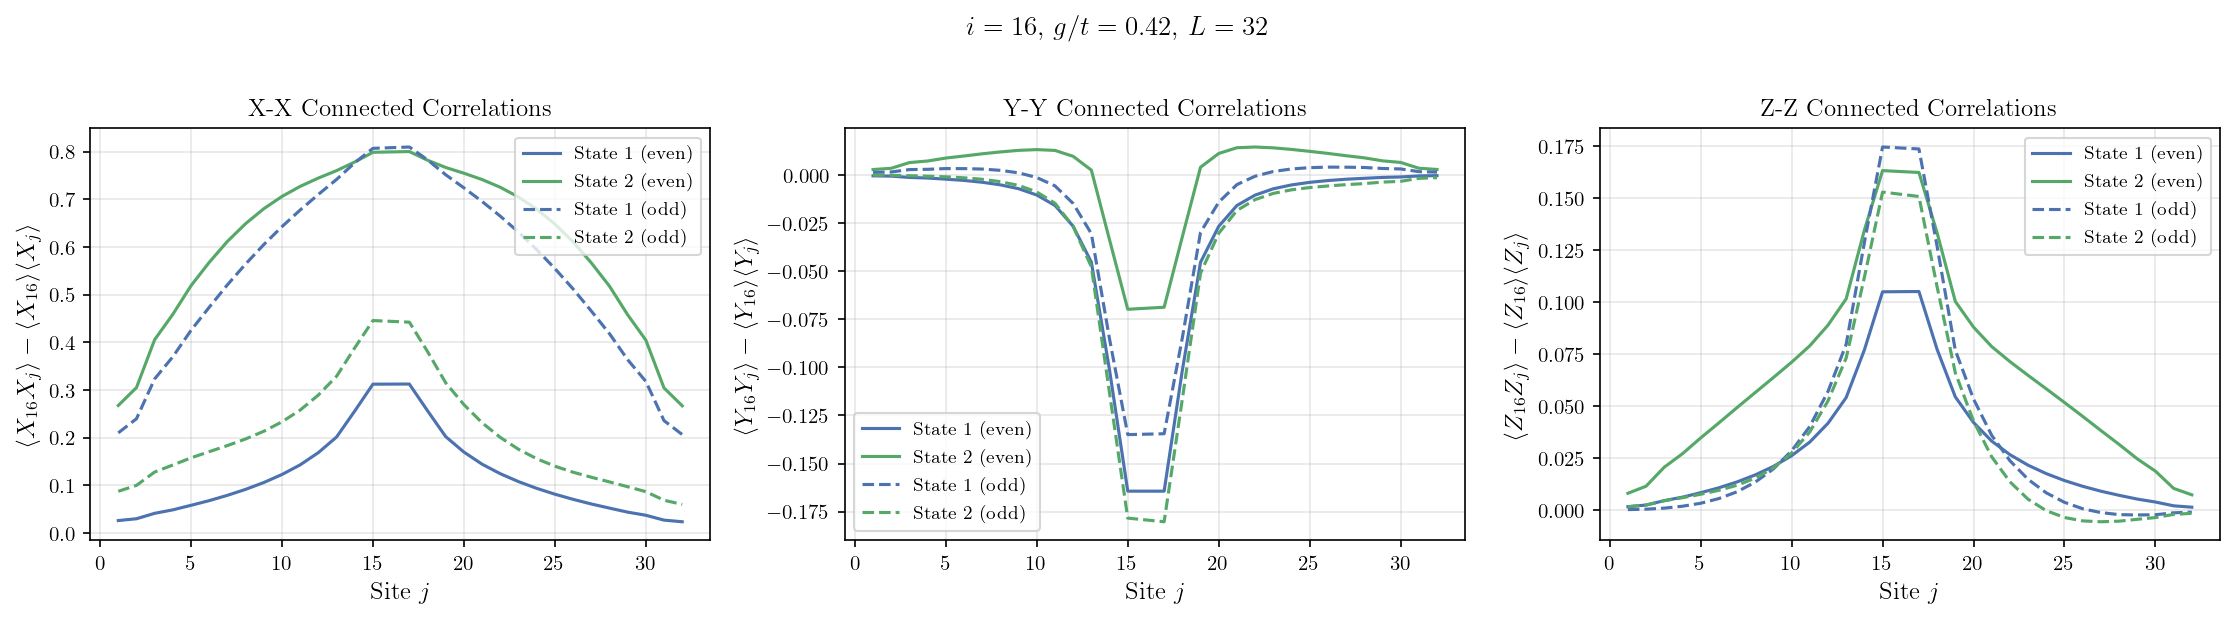

In [33]:
# Correlations
def corr_plot(connected=False):
    kind = "Connected Correlations" if connected else "Correlations"
    corr_keys = ["XXc", "YYc", "ZZc"] if connected else ["XX", "YY", "ZZ"]
    ops = ["X", "Y", "Z"]
    j_all = np.arange(L)
    mask = j_all != i_ref
    j_plot = j_all[mask] + 1
    site_label = i_ref + 1

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
    for ax, op, key in zip(axes, ops, corr_keys):
        for parity, p_label, ls in [(1, "even", "-"), (-1, "odd", "--")]:
            if (g_corr, parity) not in index:
                continue
            data = load_file(index[(g_corr, parity)])
            corr = data[key]
            for k in range(len(data["energies"])):
                ax.plot(j_plot, corr[k, i_ref, mask],
                        linestyle=ls,
                        color=COLORS[k % len(COLORS)],
                        linewidth=1.5,
                        label=f"State {k+1} ({p_label})")
        if connected:
            ylabel = rf"$\langle {op}_{{{site_label}}} {op}_j\rangle - \langle {op}_{{{site_label}}}\rangle\langle {op}_j\rangle$"
        else:
            ylabel = rf"$\langle {op}_{{{site_label}}} {op}_j\rangle$"
        ax.set_xlabel(r"Site $j$", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(rf"{op}-{op} {kind}", fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        rf"$i={site_label}$, $g/t={g_corr}$, $L={L}$",
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.show()

with h5py.File(next(iter(index.values())), "r") as f:
    L = np.array(f["X"]).shape[0]

corr_plot(connected=False)
corr_plot(connected=True)